# Leave prediction from facial motion

Analysis layer on top of the pipeline scripts. The heavy stages stay as scripts
(st1 MediaPipe + face crop, st2 FaceMap); this notebook checks their outputs, runs
what's missing, and does the modelling with the same functions st4 uses
(`scripts/st4_classify_leave.py`), so there is one copy of the analysis code.

```
raw_data ─ st1 preprocess face ─ st2 FaceMap ─ st3 trial features ─ st4 classify leave
```

Set `SESSION` below, then run all cells.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR / "scripts"))

from common import FACEMAP_DIR, PREPROCESSED_DIR, TRIAL_DIR, mean_sem
from roi_definitions import DEFAULT_ROIS, ROIS
from st4_classify_leave import (compare_models, feature_columns, load_features,
                                out_of_fold_proba)

SESSION = "session_20260930_165233"

In [2]:
# Plot style: light surface, neutral text, recessive grid. Categorical colours follow
# ROIS order, so a ROI keeps its colour in every chart.
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
ROI_COLOUR = dict(zip(ROIS, SERIES))
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 10, "lines.linewidth": 2,
})

## 1. Pipeline status

Which stage outputs exist for this session. Features count as stale when any ROI's PCs
are newer than them (st2 was rerun after st3).

In [3]:
def run(script, *args):
    """Run a pipeline script with this kernel's python and stream its output."""
    cmd = [sys.executable, str(PROJECT_DIR / "scripts" / script), "--session", SESSION, *args]
    print(">", " ".join(cmd[1:]))
    proc = subprocess.Popen(cmd, cwd=PROJECT_DIR, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in proc.stdout:
        print(line, end="")
    if proc.wait():
        raise RuntimeError("{} failed (exit code {})".format(script, proc.returncode))


def status():
    pre, fm, td = PREPROCESSED_DIR / SESSION, FACEMAP_DIR / SESSION, TRIAL_DIR / SESSION
    st1 = (pre / "face.avi").is_file() and (pre / "rois.npz").is_file()
    masks = set(np.load(pre / "rois.npz")) if st1 else set()
    pcs = {r: fm / "{}_PCs.npy".format(r) for r in ROIS}
    features = td / "X_features.npy"
    rows = [("st1", "face.avi + rois.npz", st1)]
    rows += [("st2", r, p.is_file()) for r, p in pcs.items()]
    newest_pcs = max((p.stat().st_mtime for p in pcs.values() if p.is_file()), default=0)
    st3_ok = features.is_file() and features.stat().st_mtime >= newest_pcs
    rows.append(("st3", "features" + ("" if st3_ok or not features.is_file() else " (stale)"), st3_ok))
    table = pd.DataFrame(rows, columns=["stage", "output", "ok"])
    table.attrs.update(st1=st1, missing_masks=[r for r in ROIS if r not in masks],
                       missing_pcs=[r for r, p in pcs.items() if not p.is_file()], st3=st3_ok)
    return table


s = status()
s

,stage,output,ok
0,st1,face.avi + rois.npz,True
1,st2,whole_face,True
2,st2,upper_face,True
3,st2,lower_face,True
4,st2,upper_face_no_eyes,True
5,st2,mid_forehead_to_mid_nose,True
6,st2,brows_to_mid_nose,True
7,st2,eye_band,True
8,st3,features,True


In [4]:
# Set to True to run what's missing. st1 (MediaPipe on every frame) takes several minutes;
# st2 takes ~30 s per ROI.
RUN_MISSING = False

if RUN_MISSING:
    if not s.attrs["st1"]:
        run("st1_preprocess_face.py")
    elif s.attrs["missing_masks"]:
        run("st1_preprocess_face.py", "--rois-only")   # a ROI was added to roi_definitions.py
    s = status()
    if s.attrs["missing_pcs"]:
        run("st2_run_facemap.py", "--rois", *s.attrs["missing_pcs"])
    if not status().attrs["st3"]:
        run("st3_trial_features.py")
    s = status()
s[~s["ok"]] if (~s["ok"]).any() else print("All stages up to date.")

All stages up to date.


## 2. ROIs

Horizontal bands of the face between two MediaPipe landmarks, at full face width
(`scripts/roi_definitions.py`). The main analysis uses the first four.

In [5]:
rois_info = json.loads((PREPROCESSED_DIR / SESSION / "rois.json").read_text())["rois"]
pd.DataFrame([{"roi": r, "main": r in DEFAULT_ROIS, "top": info["top_landmark"],
               "bottom": info["bottom_landmark"], "eyes cut out": info["eyes_cut_out"],
               "pixels": info["n_pixels"]} for r, info in rois_info.items()]).set_index("roi")

,main,top,bottom,eyes cut out,pixels
roi,,,,,
whole_face,True,NaN,NaN,False,30933
upper_face,True,10.0,195.0,False,14102
lower_face,True,195.0,152.0,False,16831
upper_face_no_eyes,True,10.0,195.0,True,11046
mid_forehead_to_mid_nose,False,151.0,195.0,False,12234
brows_to_mid_nose,False,9.0,195.0,False,9912
eye_band,False,8.0,197.0,False,6283


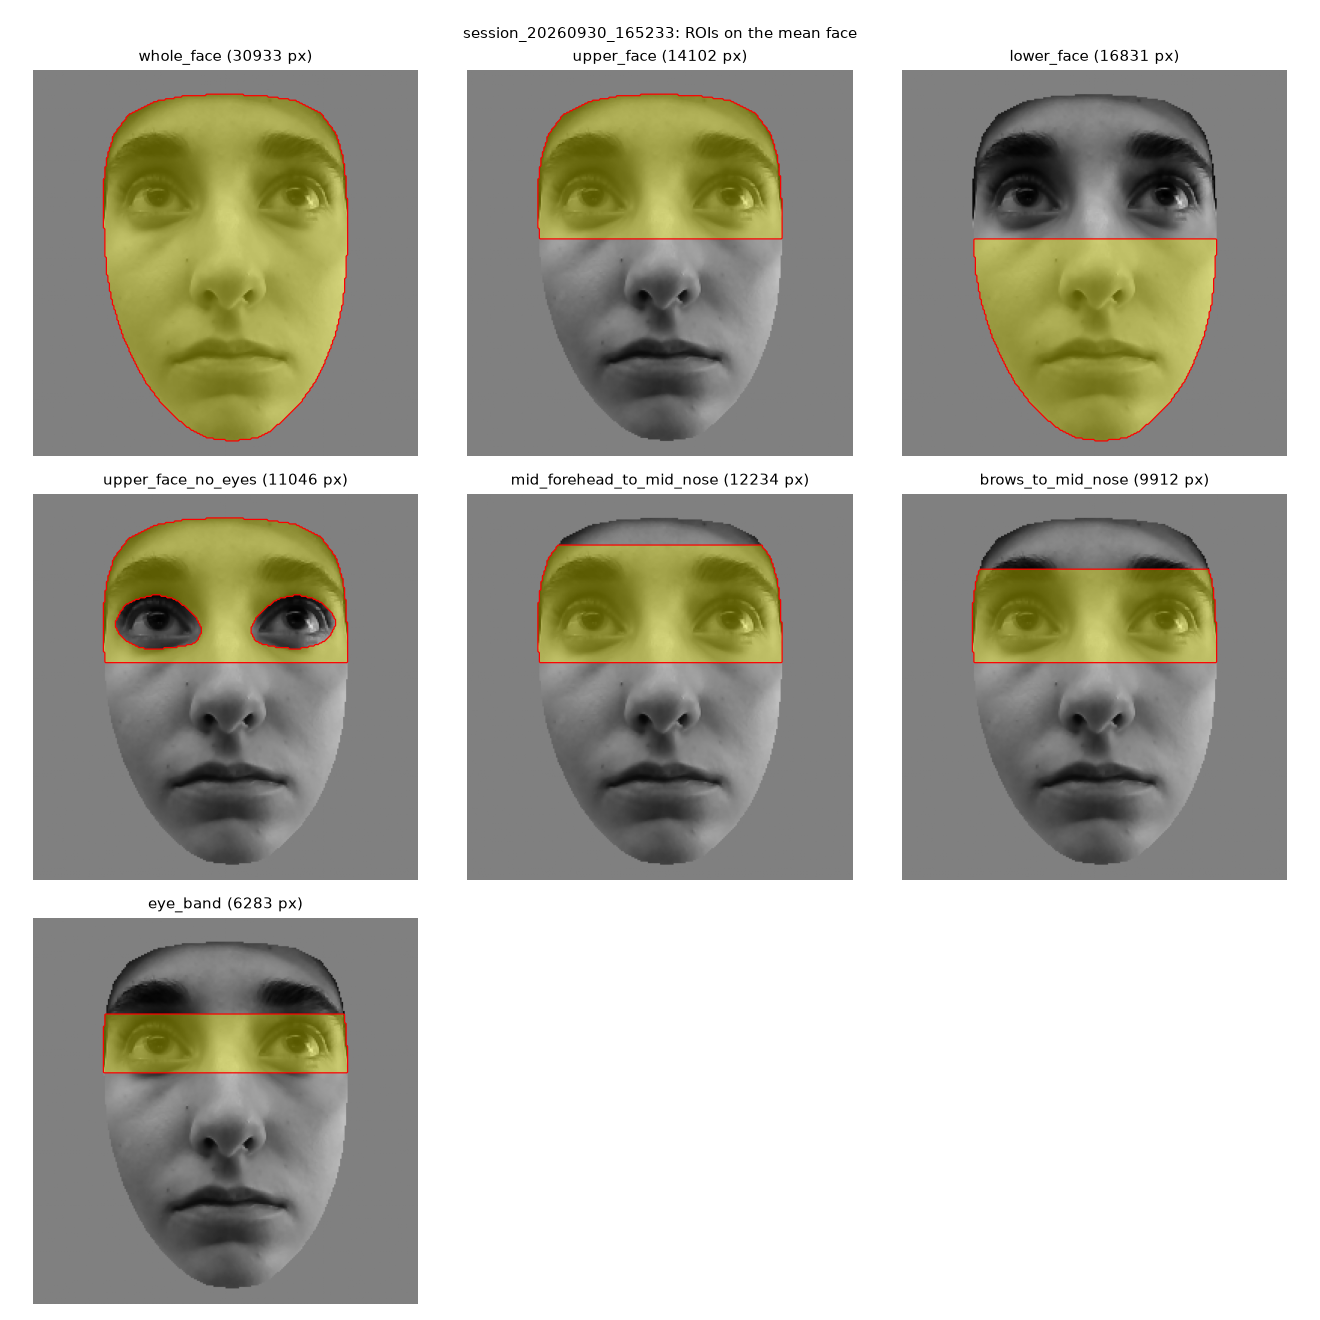

In [6]:
display(Image(str(PREPROCESSED_DIR / SESSION / "roi_preview.png"), width=900))

## 3. FaceMap components

How much of each ROI's motion the first PCs capture. Bands containing the eyes are
dominated by a few components (blinks, gaze); the lower face is spread over many.

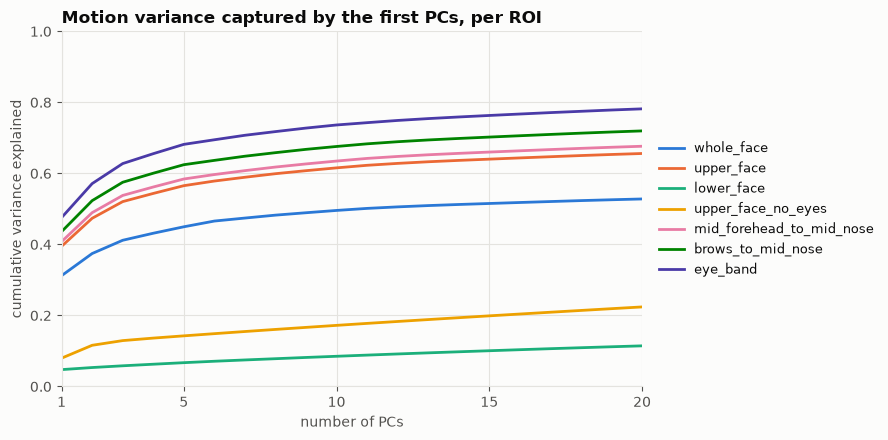

In [7]:
N_SHOW = 20
fig, ax = plt.subplots(figsize=(9, 4.5))
pcs_axis = np.arange(1, N_SHOW + 1)
for roi in ROIS:
    path = FACEMAP_DIR / SESSION / "{}_varexp.npy".format(roi)
    if not path.is_file():
        continue
    cum = np.cumsum(np.load(path)[:N_SHOW])
    ax.plot(pcs_axis, cum, color=ROI_COLOUR[roi], label=roi)
ax.set(xlabel="number of PCs", ylabel="cumulative variance explained", ylim=(0, 1),
       xlim=(1, N_SHOW), xticks=[1, 5, 10, 15, 20])
ax.set_title("Motion variance captured by the first PCs, per ROI")
ax.legend(frameon=False, fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()

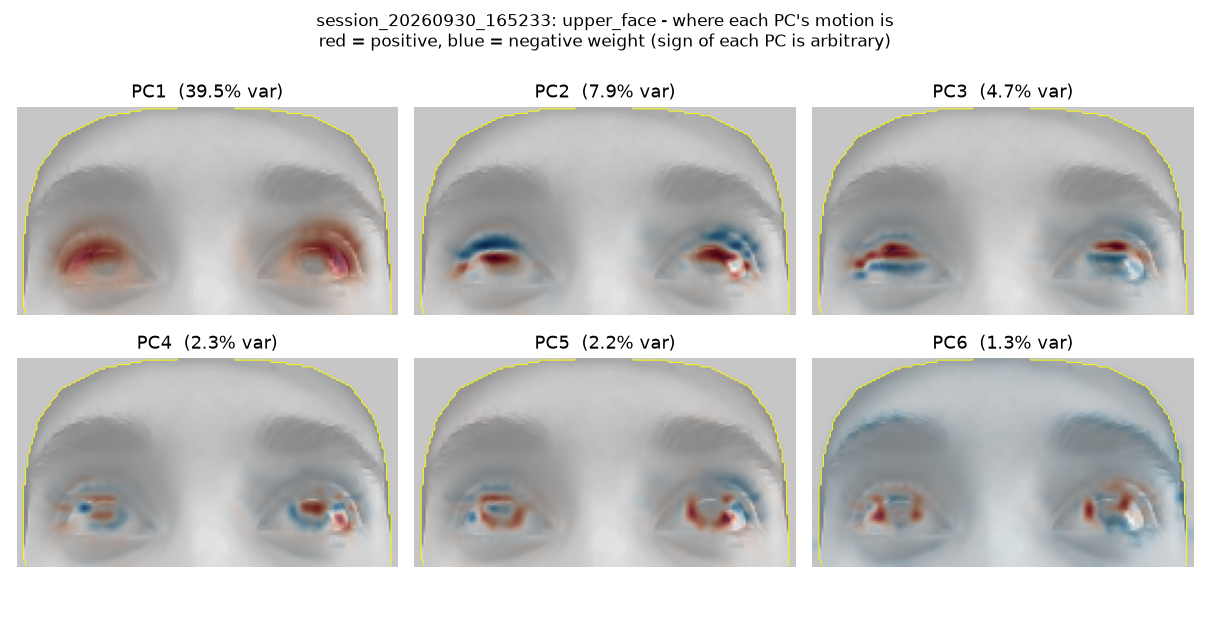

In [8]:
# Spatial masks of the first PCs for one ROI (written by st2)
ROI = "upper_face"
display(Image(str(FACEMAP_DIR / SESSION / "{}_masks.png".format(ROI)), width=900))

## 4. Features and labels

From st3: one row per trial (the last trial has no label), task features plus, per ROI
and PC, the accumulated mean / last-3 mean / slope within the site visit so far.

In [9]:
X, y, names, meta = load_features(SESSION)
visits = meta["site_visit"].values
print("{} trials x {} features; {} leave ({:.1%}), {} site visits".format(
    *X.shape, int(y.sum()), y.mean(), len(np.unique(visits))))
meta.head()

200 trials x 128 features; 31 leave (15.5%), 32 site visits


,trial_number,choice,outcome,leave,site_visit,trial_in_visit,frame_idx
0,1,right,failure,0,1,1,129
1,2,right,failure,1,1,2,217
2,3,left,failure,0,2,1,379
3,4,left,failure,0,2,2,412
4,5,left,failure,1,2,3,435


## 5. Sanity check: what the per-visit AUC measures

st4 scores each held-out visit separately. Within a visit the leave trial is always the
last one, so the per-visit AUC asks *which trial of this visit is the last*. Any feature
that grows within a visit scores well on that, whether or not it says anything about
the decision. The position in the visit alone shows the ceiling:

In [10]:
per_visit = [roc_auc_score(y[visits == v], meta["trial_in_visit"].values[visits == v])
             for v in np.unique(visits) if len(np.unique(y[visits == v])) == 2]
print("trial_in_visit alone, no model: per-visit AUC = {:.3f} ({} visits)".format(np.mean(per_visit), len(per_visit)))
print("pooled over all trials:          AUC = {:.3f}".format(roc_auc_score(y, meta["trial_in_visit"])))

trial_in_visit alone, no model: per-visit AUC = 1.000 (31 visits)
pooled over all trials:          AUC = 0.785


The pooled AUC (all held-out predictions together) instead asks whether a trial leads to
leaving, across visits, so a model has to put leave trials above stay trials of *other*
visits too. Both are reported below.

The task features are close to a rule in this session: leaving only happens after a
failure, and becomes more likely with each consecutive failure.

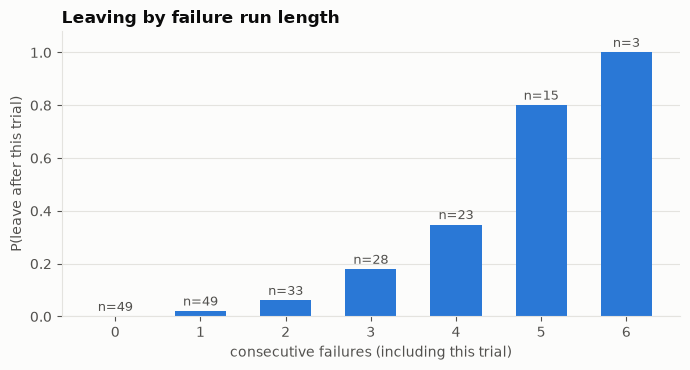

In [11]:
consec = []
for _, visit in meta.groupby("site_visit", sort=True):
    run_len = 0
    for outcome in visit["outcome"]:
        run_len = run_len + 1 if outcome == "failure" else 0
        consec.append(run_len)
by_run = pd.DataFrame({"consecutive_failures": consec, "leave": y}).groupby("consecutive_failures")["leave"].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar(by_run.index, by_run["mean"], width=0.6, color=SERIES[0])
for x, p, n in zip(by_run.index, by_run["mean"], by_run["size"]):
    ax.annotate("n={}".format(n), (x, p), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2)
ax.set(xlabel="consecutive failures (including this trial)", ylabel="P(leave after this trial)",
       ylim=(0, 1.08), xticks=by_run.index)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
ax.set_title("Leaving by failure run length")
fig.tight_layout()

## 6. Model comparison across ROIs

Elastic-net logistic regression, leave-one-visit-out: task only (A), face PCs only (B),
task + face (C). Each ROI set uses its own face columns from the same feature table.
Takes a minute or two.

In [12]:
ROI_SETS = {"main four": DEFAULT_ROIS, **{r: [r] for r in ROIS}}
available = {m.split("_PC")[0] for m in names if "_PC" in m}
ROI_SETS = {k: v for k, v in ROI_SETS.items() if set(v) <= available}

results, pooled, folds = {}, {}, {}
for label, rois in ROI_SETS.items():
    results[label] = compare_models(X, y, visits, names, rois)
    task, face = feature_columns(names, rois)
    pooled[label] = {key: roc_auc_score(y, out_of_fold_proba(X[:, cols], y, visits))
                     for key, cols in (("A", task), ("B", face), ("C", task | face))}
    folds[label] = results[label]["B"]["fold_aucs"]
    print("done:", label)

table = pd.DataFrame({
    label: {**{"{} per-visit".format(k): "{:.3f} ± {:.3f}".format(r[k]["mean"], r[k]["sem"]) for k in "ABC"},
            **{"{} pooled".format(k): round(pooled[label][k], 3) for k in "ABC"},
            "face features": r["B"]["n_features"]}
    for label, r in results.items()}).T
table

done: main four
done: whole_face
done: upper_face
done: lower_face
done: upper_face_no_eyes
done: mid_forehead_to_mid_nose
done: brows_to_mid_nose
done: eye_band


,A per-visit,B per-visit,C per-visit,A pooled,B pooled,C pooled,face features
main four,1.000 ± 0.000,0.638 ± 0.068,0.989 ± 0.011,0.893,0.517,0.922,72
whole_face,1.000 ± 0.000,0.663 ± 0.062,0.992 ± 0.008,0.893,0.57,0.91,18
upper_face,1.000 ± 0.000,0.693 ± 0.059,1.000 ± 0.000,0.893,0.576,0.902,18
lower_face,1.000 ± 0.000,0.440 ± 0.072,0.989 ± 0.011,0.893,0.482,0.912,18
upper_face_no_eyes,1.000 ± 0.000,0.597 ± 0.069,0.984 ± 0.016,0.893,0.52,0.886,18
mid_forehead_to_mid_nose,1.000 ± 0.000,0.683 ± 0.058,1.000 ± 0.000,0.893,0.565,0.9,18
brows_to_mid_nose,1.000 ± 0.000,0.673 ± 0.056,1.000 ± 0.000,0.893,0.569,0.905,18
eye_band,1.000 ± 0.000,0.669 ± 0.061,1.000 ± 0.000,0.893,0.6,0.906,18


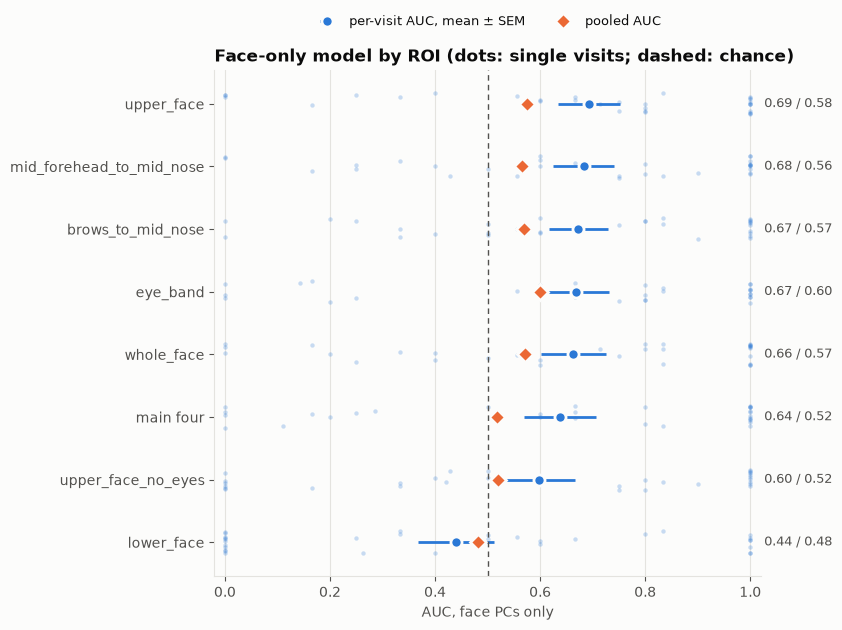

In [13]:
order = sorted(results, key=lambda k: results[k]["B"]["mean"])
fig, ax = plt.subplots(figsize=(8.5, 0.6 * len(order) + 1.6))
ax.set_axisbelow(True)
rng = np.random.default_rng(0)
for i, label in enumerate(order):
    f = np.array(folds[label])
    ax.scatter(f, i + rng.uniform(-0.18, 0.18, len(f)), s=10, color=SERIES[0], alpha=0.25, linewidths=0)
    m, s = results[label]["B"]["mean"], results[label]["B"]["sem"]
    ax.errorbar(m, i, xerr=s, fmt="o", ms=8, color=SERIES[0], elinewidth=2, capsize=0,
                markeredgecolor=SURFACE, markeredgewidth=2, label="per-visit AUC, mean ± SEM" if i == 0 else None)
    ax.plot(pooled[label]["B"], i, "D", ms=8, color=SERIES[1], markeredgecolor=SURFACE,
            markeredgewidth=2, label="pooled AUC" if i == 0 else None)
    ax.annotate("{:.2f} / {:.2f}".format(m, pooled[label]["B"]), (1.0, i), xytext=(10, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK_2)
ax.axvline(0.5, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
ax.set(yticks=range(len(order)), yticklabels=order, xlim=(-0.02, 1.02), xlabel="AUC, face PCs only")
ax.grid(axis="y", visible=False)
ax.set_title("Face-only model by ROI (dots: single visits; dashed: chance)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=False, fontsize=9, loc="lower center",
          bbox_to_anchor=(0.5, 1.06), ncols=2)   # same order as the "per-visit / pooled" labels
fig.tight_layout()

## Notes

- The per-visit AUC of model A is 1 by construction here (section 5), so model C can't
  show whether the face adds information beyond the task. The pooled AUCs, and model B
  against the `trial_in_visit` ceiling, are the more informative comparisons.
- One session, 31 leave trials: differences between ROI sets of a few hundredths are
  well within the SEM.